In [1]:
import sys
print(sys.executable)

c:\Users\esham\AppData\Local\Programs\Python\Python312\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load the dataset
df = pd.read_csv("../dataset/DailyDelhiClimateTrain.csv")

# Display first 5 rows
df.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [4]:
df.shape

(1462, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


In [6]:
df.describe()

,meantemp,humidity,wind_speed,meanpressure
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,25.495521,60.771702,6.802209,1011.104548
std,7.348103,16.769652,4.561602,180.231668
min,6.000000,13.428571,0.000000,-3.041667
25%,18.857143,50.375000,3.475000,1001.580357
50%,27.714286,62.625000,6.221667,1008.563492
75%,31.305804,72.218750,9.238235,1014.944901
max,38.714286,100.000000,42.220000,7679.333333


In [7]:
df.isnull().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [8]:
df["date"] = pd.to_datetime(df["date"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1462 non-null   datetime64[ns]
 1   meantemp      1462 non-null   float64       
 2   humidity      1462 non-null   float64       
 3   wind_speed    1462 non-null   float64       
 4   meanpressure  1462 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 57.2 KB


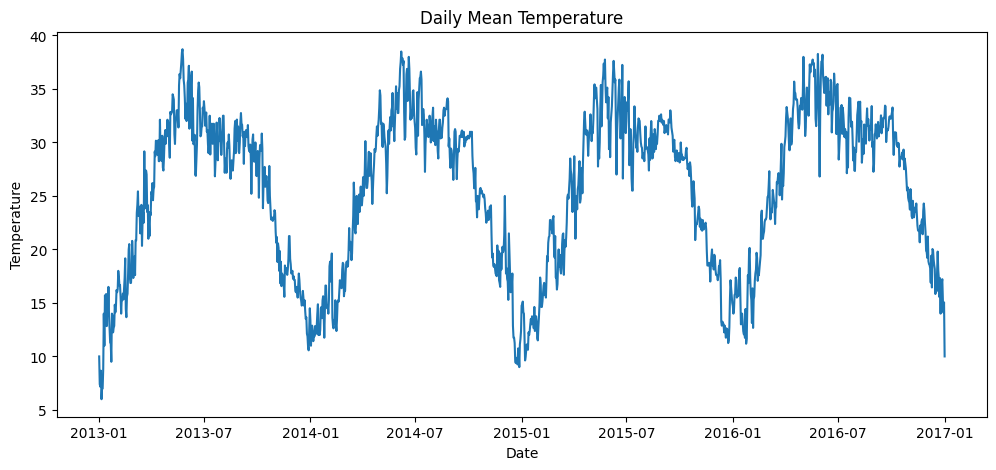

In [9]:
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["meantemp"])
plt.title("Daily Mean Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

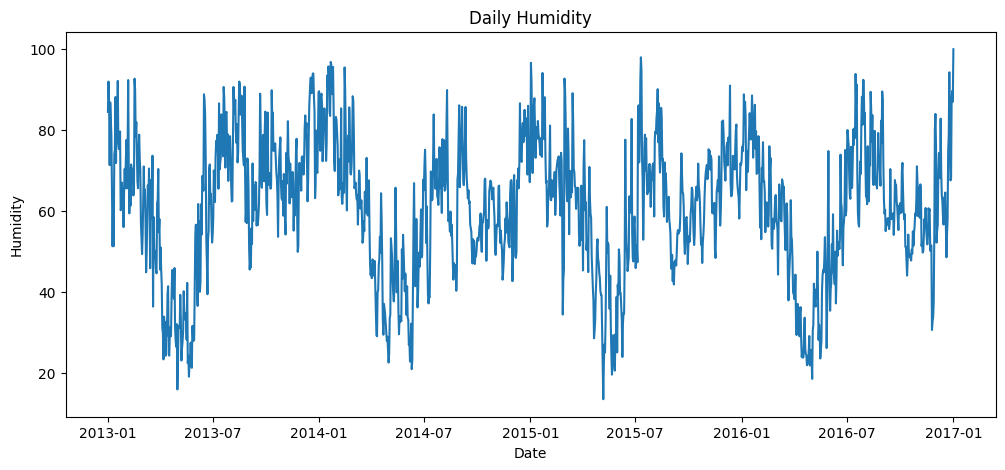

In [10]:
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["humidity"])
plt.title("Daily Humidity")
plt.xlabel("Date")
plt.ylabel("Humidity")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

# Features (Input)
X = df[["humidity", "wind_speed", "meanpressure"]]

# Target (Output)
y = df["meantemp"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1169, 3)
Testing data shape: (293, 3)


In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
predictions = model.predict(X_test)

print(predictions[:10])

[32.77204602 23.33753171 26.09260621 35.59737618 22.63007728 22.8878447
 19.21373771 24.44070304 24.76018546 31.27167743]


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Absolute Error: 5.202927351069218
Mean Squared Error: 37.16494033014128
R2 Score: 0.30868066664475546


In [16]:
import joblib

joblib.dump(model, "../models/weather_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [15]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
0,35.875000,32.772046
1,18.000000,23.337532
2,15.250000,26.092606
3,38.500000,35.597376
4,24.000000,22.630077
5,31.000000,22.887845
6,28.375000,19.213738
7,23.714286,24.440703
8,26.000000,24.760185
9,35.000000,31.271677
